# FASE IV — Caracterización de Perfiles de Riesgo (Notebook Unificado)
**Proyecto:** Segmentación Avanzada de Riesgo Hipotecario — Fannie Mae SF

---

## Arquitectura de la caracterización

La caracterización opera en **dos capas complementarias**:

| Capa | Fuente | Qué responde |
|---|---|---|
| **Latente** | Factores AFE (6 dims) | ¿Por qué el algoritmo separó estos clusters? |
| **Observable** | Subset A (variables originales) | ¿Qué significa en términos de negocio real? |

Ambas capas son necesarias. Los factores AFE permiten validar estadísticamente
que la separación es real (Kruskal-Wallis). Las variables originales traducen
esa separación a lenguaje de riesgo crediticio (FICO, LTV, mora, vintage).

---

## Inputs
- `cluster_labels.csv` — etiquetas de los 4 métodos por loan_id
- `afe_latent_space.csv` — 6 factores AFE por loan_id
- `subset_a.csv` — 41 variables originales por loan_id (49,735 préstamos)

## Método canónico: **DEC**
- Cluster más balanceado (std=361 vs KMeans std=760, HC std=1,139)
- NMI más alto con GMM (0.409) → mayor concordancia con métodos lineales
- Mejor separación visual en tSNE


## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# ── Rutas de entrada ────────────────────────────────────────────────────────
# Ajustar según entorno (local o Colab)
LABELS_PATH  = 'C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/4_CLUSTER/cluster_labels.csv'
AFE_PATH     = 'C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/2_AFE_AFC/afe_latent_space_unified.csv'          # latent_space_unified.csv
SUBSET_A_PATH = 'C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/data/gold/subset_a/part-00000-5946d355-f9d8-45c1-be26-998f18db765b-c000.csv'
OUT_DIR      = Path('output_caracterizacion')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constantes ───────────────────────────────────────────────────────────────
K           = 6
CLUSTER_COL = 'cluster_dec'

PALETTE = {
    0: '#e07b39', 1: '#2196F3', 2: '#4CAF50',
    3: '#9C27B0', 4: '#F44336', 5: '#795548',
}
PALETTE_LIST = [PALETTE[i] for i in range(K)]

CLUSTER_NAMES = {
    0: 'Stable / Mora Diferida',
    1: 'COVID Sano Retail',
    2: 'COVID Sano Jumbo',
    3: 'Transición / Refinanciamiento',
    4: 'COVID Alto Riesgo',
    5: 'Stable / Mora Crítica',
}
RISK_LEVEL = {
    0: 'MODERADO-ALTO', 1: 'BAJO', 2: 'BAJO',
    3: 'MODERADO',      4: 'ALTO', 5: 'MUY ALTO',
}
RISK_COLORS = {
    'BAJO': '#4CAF50', 'MODERADO': '#FFC107',
    'MODERADO-ALTO': '#FF9800', 'ALTO': '#F44336', 'MUY ALTO': '#B71C1C',
}

AFE_FEATURES = [
    'orig_F_crediticia', 'orig_F_apalancamiento', 'orig_F_exposicion',
    'orig_F_contractual', 'comp_F_deterioro', 'macro_F_cohorte',
]
AFE_LABELS = {
    'orig_F_crediticia':     'F_Crediticia\n(FICO, historial)',
    'orig_F_apalancamiento': 'F_Apalancamiento\n(LTV, DTI)',
    'orig_F_exposicion':     'F_Exposición\n(UPB, tipo préstamo)',
    'orig_F_contractual':    'F_Contractual\n(propósito, canal)',
    'comp_F_deterioro':      'F_Deterioro\n(mora acumulada)',
    'macro_F_cohorte':       'F_Cohorte\n(año, vintage)',
}

print('✓ Librerías y configuración cargadas')


✓ Librerías y configuración cargadas


## 1. Carga y JOIN de los tres archivos

In [3]:
# Cargar los tres archivos
labels_df = pd.read_csv(LABELS_PATH,   dtype={'loan_id': str})
afe_df    = pd.read_csv(AFE_PATH,      dtype={'loan_id': str})
subset_a  = pd.read_csv(SUBSET_A_PATH, dtype={'loan_id': str})

# Normalizar loan_id: eliminar ceros a la izquierda para igualar formatos
# (labels: '97667466' | subset_a: '000097667466')
for d in [labels_df, afe_df, subset_a]:
    d['loan_id_str'] = d['loan_id'].str.lstrip('0')

# JOIN: labels + AFE + Subset A
df = (labels_df
      .merge(afe_df[['loan_id_str'] + AFE_FEATURES + ['state_ord', 'property_state']
                     if 'property_state' in afe_df.columns
                     else ['loan_id_str'] + AFE_FEATURES],
             on='loan_id_str', how='inner')
      .merge(subset_a.drop(columns=['loan_id'], errors='ignore'),
             on='loan_id_str', how='inner'))

print(f'Labels:      {len(labels_df):,} loans')
print(f'AFE space:   {len(afe_df):,} loans')
print(f'Subset A:    {len(subset_a):,} loans')
print(f'JOIN final:  {len(df):,} loans con datos completos')
print()

# Distribución por cluster DEC
print('Distribución por cluster DEC:')
for c in range(K):
    n   = (df[CLUSTER_COL] == c).sum()
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  C{c} [{CLUSTER_NAMES[c]:<32}]: {n:>5,}  ({pct:>5.1f}%)  {bar}')


Labels:      5,267 loans
AFE space:   5,267 loans
Subset A:    49,735 loans
JOIN final:  5,267 loans con datos completos

Distribución por cluster DEC:
  C0 [Stable / Mora Diferida          ]: 1,295  ( 24.6%)  ████████████
  C1 [COVID Sano Retail               ]:   931  ( 17.7%)  ████████
  C2 [COVID Sano Jumbo                ]: 1,142  ( 21.7%)  ██████████
  C3 [Transición / Refinanciamiento   ]:   268  (  5.1%)  ██
  C4 [COVID Alto Riesgo               ]:   707  ( 13.4%)  ██████
  C5 [Stable / Mora Crítica           ]:   924  ( 17.5%)  ████████


## 2. Validación cruzada — estabilidad entre los 4 métodos

**ARI (Adjusted Rand Index):** mide cuántos pares de loans son asignados al mismo
cluster por dos métodos. ARI = 1.0 = acuerdo perfecto; ARI = 0.0 = acuerdo aleatorio.

**NMI (Normalized Mutual Information):** mide la información compartida entre
dos asignaciones. Más robusto que ARI ante clusters de tamaño desigual.

Los loans donde los **4 métodos coinciden** tienen asignación de alta confianza
y son los que menos necesitan revisión manual.


In [4]:
metodos = {
    'K-Means': 'cluster_kmeans',
    'GMM':     'cluster_gmm',
    'HC Ward': 'cluster_hc',
    'DEC':     'cluster_dec',
}
nombres = list(metodos.keys())

# Matrices ARI y NMI
ari_mat = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
nmi_mat = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for m1 in nombres:
    for m2 in nombres:
        a = adjusted_rand_score(df[metodos[m1]], df[metodos[m2]])
        n = normalized_mutual_info_score(df[metodos[m1]], df[metodos[m2]])
        ari_mat.loc[m1, m2] = round(a, 3)
        nmi_mat.loc[m1, m2] = round(n, 3)

print('── ARI ──')
display(ari_mat.style
        .background_gradient(cmap='YlGn', vmin=0, vmax=1)
        .format('{:.3f}'))

print('── NMI ──')
display(nmi_mat.style
        .background_gradient(cmap='Blues', vmin=0, vmax=1)
        .format('{:.3f}'))

# Balance por método
print('\nBalance de clusters (std de tamaños — menor = más balanceado):')
for name, col in metodos.items():
    sizes = df[col].value_counts()
    print(f'  {name:<10}: std={sizes.std():.0f}  |  '
          f'min={sizes.min():<5}  max={sizes.max():<5}  '
          f'{"✓ BALANCEADO" if sizes.std() < 500 else "⚠ DESBALANCEADO"}')


── ARI ──


,K-Means,GMM,HC Ward,DEC
K-Means,1.000,0.182,0.322,0.045
GMM,0.182,1.000,0.325,0.271
HC Ward,0.322,0.325,1.000,0.054
DEC,0.045,0.271,0.054,1.000


── NMI ──


,K-Means,GMM,HC Ward,DEC
K-Means,1.000,0.394,0.483,0.151
GMM,0.394,1.000,0.522,0.409
HC Ward,0.483,0.522,1.000,0.150
DEC,0.151,0.409,0.150,1.000



Balance de clusters (std de tamaños — menor = más balanceado):
  K-Means   : std=760  |  min=187    max=2142   ⚠ DESBALANCEADO
  GMM       : std=463  |  min=268    max=1582   ✓ BALANCEADO
  HC Ward   : std=1139  |  min=193    max=3175   ⚠ DESBALANCEADO
  DEC       : std=361  |  min=268    max=1295   ✓ BALANCEADO


Loans alta confianza (4 métodos coinciden): 0  (0.0%)
Loans con discrepancia (revisión manual)  : 5,267  (100.0%)


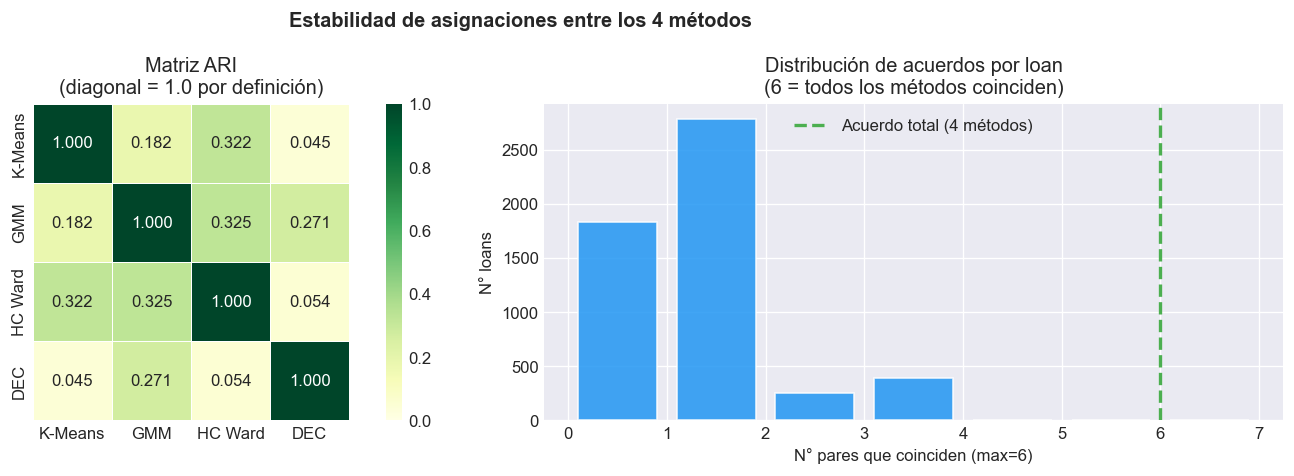

In [5]:
# Loans de alta confianza: todos los pares de métodos coinciden
pares = [
    ('cluster_kmeans', 'cluster_gmm'),
    ('cluster_kmeans', 'cluster_hc'),
    ('cluster_kmeans', 'cluster_dec'),
    ('cluster_gmm',    'cluster_hc'),
    ('cluster_gmm',    'cluster_dec'),
    ('cluster_hc',     'cluster_dec'),
]
df['n_acuerdos']     = sum((df[c1] == df[c2]).astype(int) for c1, c2 in pares)
df['alta_confianza'] = (df['n_acuerdos'] == 6)

pct_conf = df['alta_confianza'].mean() * 100
print(f'Loans alta confianza (4 métodos coinciden): '
      f'{df["alta_confianza"].sum():,}  ({pct_conf:.1f}%)')
print(f'Loans con discrepancia (revisión manual)  : '
      f'{(~df["alta_confianza"]).sum():,}  ({100-pct_conf:.1f}%)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Estabilidad de asignaciones entre los 4 métodos',
             fontsize=12, fontweight='bold')

sns.heatmap(ari_mat.astype(float), annot=True, fmt='.3f',
            cmap='YlGn', vmin=0, vmax=1, ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Matriz ARI\n(diagonal = 1.0 por definición)')

axes[1].hist(df['n_acuerdos'], bins=range(0, 8),
             color='#2196F3', edgecolor='white', alpha=0.85, rwidth=0.8)
axes[1].axvline(6, ls='--', color='#4CAF50', lw=2, label='Acuerdo total (4 métodos)')
axes[1].set_title('Distribución de acuerdos por loan\n(6 = todos los métodos coinciden)')
axes[1].set_xlabel('N° pares que coinciden (max=6)')
axes[1].set_ylabel('N° loans')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_ari_estabilidad.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Capa latente — Perfiles por factores AFE

Aquí respondemos: **¿por qué el algoritmo separó estos clusters?**

Cada factor AFE representa un constructo latente no observable directamente:

| Factor | Constructo | Variables que lo forman |
|---|---|---|
| `orig_F_crediticia` | Calidad crediticia | FICO, historial de pago |
| `orig_F_apalancamiento` | Nivel de deuda | LTV, DTI, MI |
| `orig_F_exposicion` | Tamaño del préstamo | UPB, plazo, tasa |
| `orig_F_contractual` | Perfil contractual | Canal, propósito, ocupación |
| `comp_F_deterioro` | Deterioro acumulado | Meses mora, max delinquency |
| `macro_F_cohorte` | Efecto macroeconómico | Año originación, vintage |


In [6]:
# Medias de factores AFE por cluster
prof_afe = df.groupby(CLUSTER_COL)[AFE_FEATURES].mean().round(4)
prof_afe['n_loans'] = df.groupby(CLUSTER_COL).size()
prof_afe['pct_%']   = (prof_afe['n_loans'] / len(df) * 100).round(1)

print(f'PERFILES POR FACTORES AFE — DEC (K={K})')
display(prof_afe.style
        .background_gradient(subset=AFE_FEATURES, cmap='RdYlGn')
        .format({c: '{:.4f}' for c in AFE_FEATURES})
        .format({'n_loans': '{:,}', 'pct_%': '{:.1f}%'}))


PERFILES POR FACTORES AFE — DEC (K=6)


,orig_F_crediticia,orig_F_apalancamiento,orig_F_exposicion,orig_F_contractual,comp_F_deterioro,macro_F_cohorte,n_loans,pct_%
cluster_dec,,,,,,,,
0,0.006500,0.064100,0.177800,0.126800,0.125300,-0.703500,"1,295",24.6%
1,0.066700,0.057600,0.744600,0.259700,-0.369900,0.270300,931,17.7%
2,0.108900,0.052800,1.120200,0.347300,-0.352400,1.002400,"1,142",21.7%
3,0.126400,-0.671900,0.168000,-0.821100,-0.174600,-0.190200,268,5.1%
4,0.099300,0.054400,0.978700,0.313800,0.153000,0.910200,707,13.4%
5,0.006800,0.064300,0.154700,0.121100,0.465600,-0.641700,924,17.5%


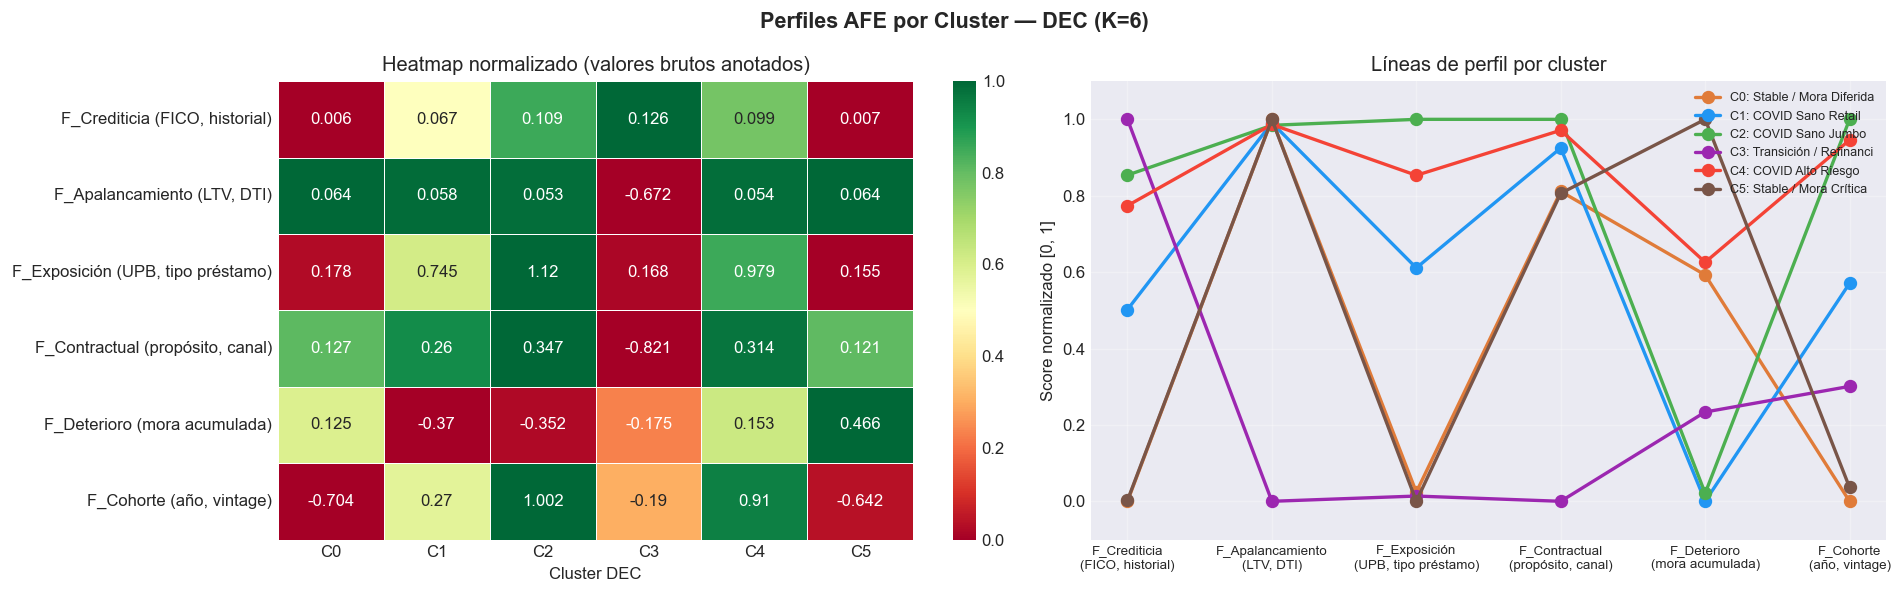

In [7]:
# Heatmap AFE normalizado + líneas de perfil
prof_n    = prof_afe[AFE_FEATURES].copy()
prof_norm = (prof_n - prof_n.min()) / (prof_n.max() - prof_n.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Perfiles AFE por Cluster — DEC (K={K})', fontsize=13, fontweight='bold')

# Heatmap
sns.heatmap(prof_norm.T,
            annot=prof_n.T.round(3), fmt='g',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[0],
            xticklabels=[f'C{c}' for c in range(K)],
            yticklabels=[AFE_LABELS[f].replace('\n', ' ') for f in AFE_FEATURES])
axes[0].set_title('Heatmap normalizado (valores brutos anotados)')
axes[0].set_xlabel('Cluster DEC')

# Líneas de perfil
for c in range(K):
    vals = prof_norm.loc[c].values
    axes[1].plot(range(len(AFE_FEATURES)), vals, 'o-',
                 color=PALETTE[c], linewidth=2, markersize=7,
                 label=f'C{c}: {CLUSTER_NAMES[c][:22]}')
axes[1].set_xticks(range(len(AFE_FEATURES)))
axes[1].set_xticklabels([AFE_LABELS[f].replace('\n', '\n') for f in AFE_FEATURES],
                         fontsize=8)
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_ylabel('Score normalizado [0, 1]')
axes[1].set_title('Líneas de perfil por cluster')
axes[1].legend(fontsize=7.5, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_perfiles_afe.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Validación estadística — Kruskal-Wallis

Confirma que las diferencias entre clusters son **estadísticamente significativas**
en cada factor AFE, no producto del azar.

- **H** = estadístico de Kruskal-Wallis (cuanto mayor, más separación)
- **p < 0.05** → la separación es real con 95% de confianza


In [8]:
print(f'Test Kruskal-Wallis por factor AFE (K={K} clusters)')
print(f'  {"Factor":<28} {"H-stat":>9}  {"p-value":>12}  Resultado')
print('  ' + '-' * 65)

resultados_kw = {}
for factor in AFE_FEATURES:
    grupos = [df[df[CLUSTER_COL] == cl][factor].dropna().values
              for cl in sorted(df[CLUSTER_COL].unique())]
    H, p = kruskal(*grupos)
    sig  = '✓ SIGNIFICATIVO (p<0.05)' if p < 0.05 else '✗ no significativo'
    resultados_kw[factor] = {'H': round(H, 2), 'p': round(p, 6)}
    print(f'  {factor:<28} {H:>9.2f}  {p:>12.2e}  {sig}')

n_sig = sum(1 for v in resultados_kw.values() if v['p'] < 0.05)
print(f'\n  {n_sig}/{len(AFE_FEATURES)} factores con separación estadísticamente significativa')


Test Kruskal-Wallis por factor AFE (K=6 clusters)
  Factor                          H-stat       p-value  Resultado
  -----------------------------------------------------------------
  orig_F_crediticia               398.88      5.17e-84  ✓ SIGNIFICATIVO (p<0.05)
  orig_F_apalancamiento          1065.62     3.72e-228  ✓ SIGNIFICATIVO (p<0.05)
  orig_F_exposicion               375.23      6.45e-79  ✓ SIGNIFICATIVO (p<0.05)
  orig_F_contractual              997.29     2.32e-213  ✓ SIGNIFICATIVO (p<0.05)
  comp_F_deterioro               2745.48      0.00e+00  ✓ SIGNIFICATIVO (p<0.05)
  macro_F_cohorte                3100.26      0.00e+00  ✓ SIGNIFICATIVO (p<0.05)

  6/6 factores con separación estadísticamente significativa


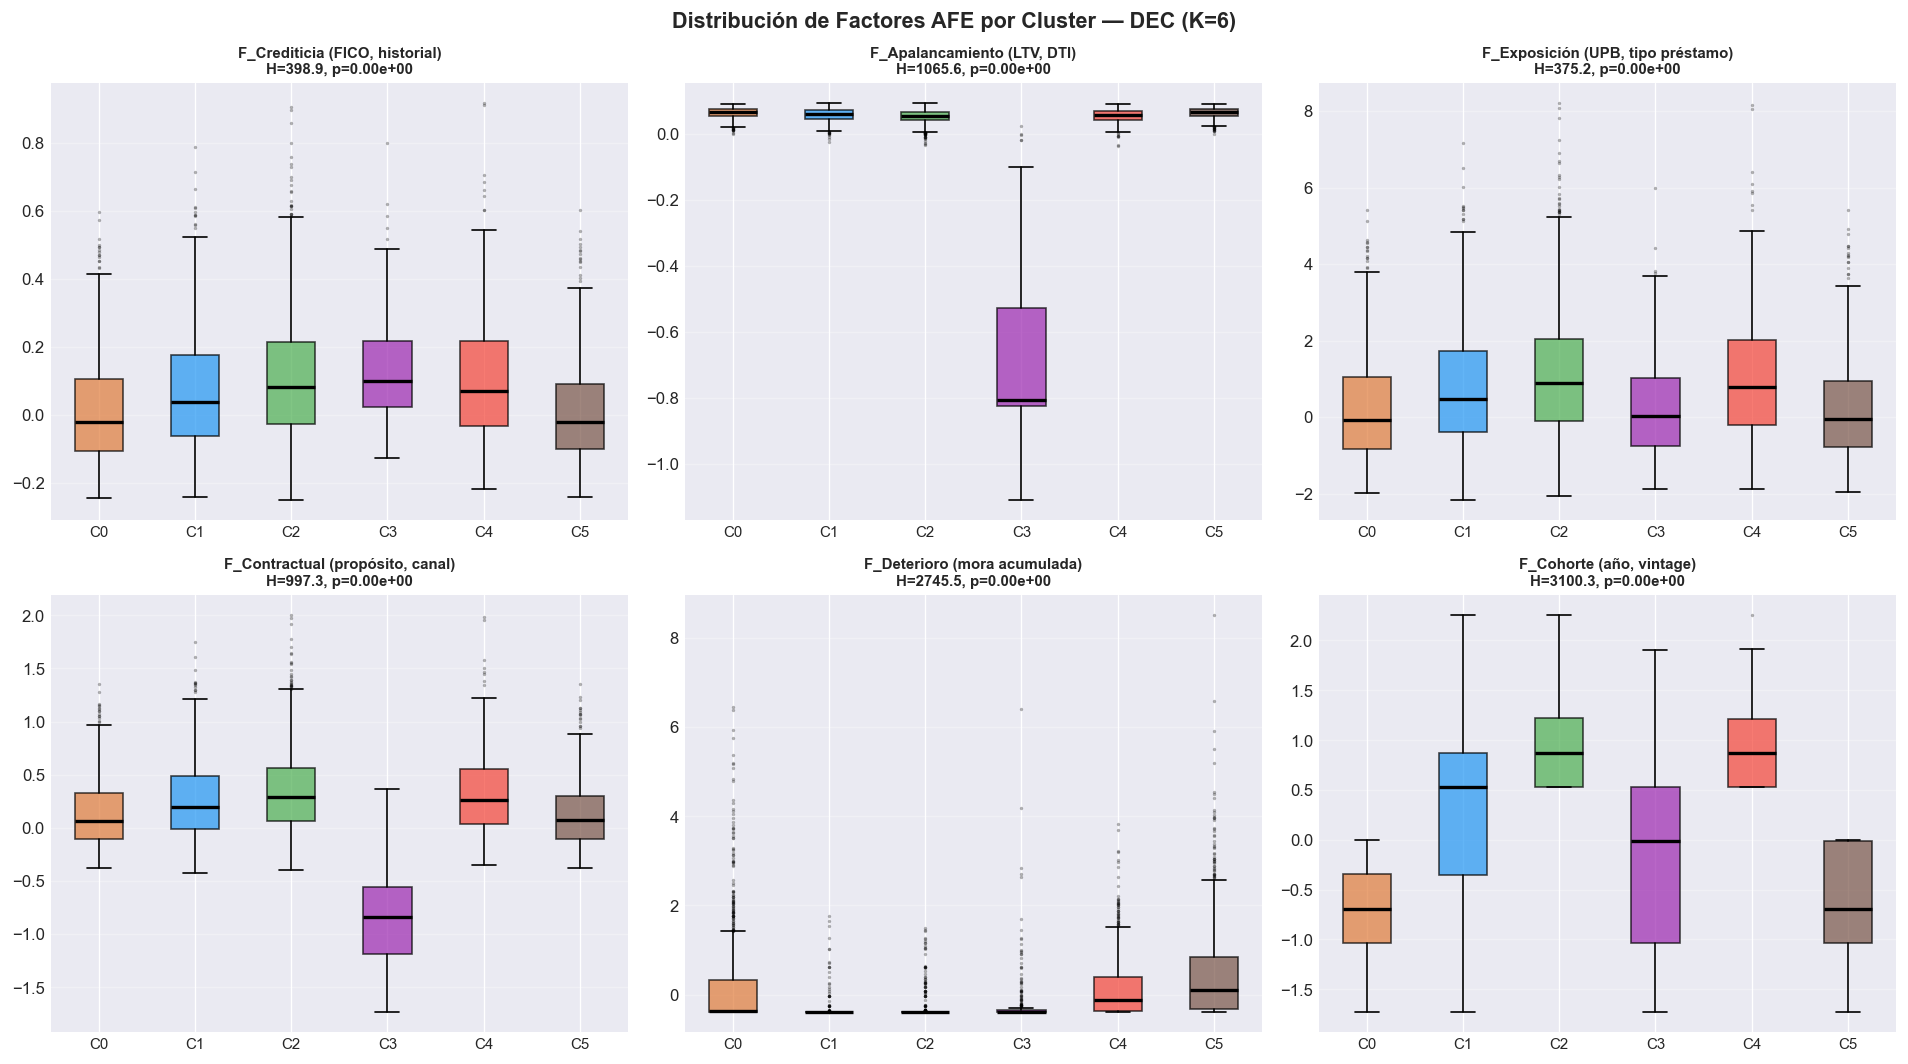

In [9]:
# Boxplots de los 6 factores AFE por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle(f'Distribución de Factores AFE por Cluster — DEC (K={K})',
             fontsize=13, fontweight='bold')

for ax, factor in zip(axes, AFE_FEATURES):
    data = [df[df[CLUSTER_COL] == cl][factor].dropna().values
            for cl in range(K)]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], PALETTE_LIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    H = resultados_kw[factor]['H']
    p = resultados_kw[factor]['p']
    ax.set_title(f'{AFE_LABELS[factor].replace(chr(10), " ")}\nH={H:.1f}, p={p:.2e}',
                 fontsize=9, fontweight='bold')
    ax.set_xticks(range(1, K + 1))
    ax.set_xticklabels([f'C{c}' for c in range(K)], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_boxplots_afe.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Capa observable — Perfiles con variables originales (Subset A)

Aquí respondemos: **¿qué significa cada cluster en términos de negocio?**

Las variables están en escala real e interpretable para gestores de cartera:
FICO=734, LTV=93%, ever_90DPD=44.2%, Forbearance=44.1%.


In [10]:
# Variables numéricas para caracterización
num_vars = {
    # Originación
    'borrower_credit_score': 'FICO Score',
    'dti':                   'DTI (%)',
    'orig_ltv':              'LTV Orig (%)',
    'orig_interest_rate':    'Tasa Interés (%)',
    'orig_upb':              'UPB Orig ($)',
    'orig_loan_term':        'Plazo (meses)',
    'mi_percentage':         'MI (%)',
    # Comportamiento
    'max_delinquency_status':    'Max Morosidad',
    'months_delinquent_30plus':  'Meses 30+DPD',
    'months_delinquent_90plus':  'Meses 90+DPD',
    'loan_duration_months':      'Duración (meses)',
    'time_to_first_delinquency': 'Tiempo 1a Mora (m)',
    'ph_months_delinquent_24':   'Mora LPH-24 (m)',
    # Outcomes
    'is_default':      'Default (%)',
    'ever_d90':        'Ever 90+DPD (%)',
    'ever_d180':       'Ever 180+DPD (%)',
    'ever_foreclosed': 'Ever Ejecutado (%)',
    'had_forbearance': 'Forbearance (%)',
    'ever_modified':   'Modificado (%)',
    'net_severity':    'Severidad Neta',
}

means   = df.groupby(CLUSTER_COL)[list(num_vars.keys())].mean().round(3)
medians = df.groupby(CLUSTER_COL)[list(num_vars.keys())].median().round(3)

# Tabla de medias con coloreado condicional en outcomes de riesgo
risk_cols = ['is_default', 'ever_d90', 'ever_d180', 'ever_foreclosed',
             'had_forbearance', 'ever_modified']

display(means.rename(
    columns=num_vars,
    index={c: f'C{c}: {CLUSTER_NAMES[c]}' for c in range(K)}
).style
 .background_gradient(subset=[num_vars[c] for c in risk_cols], cmap='RdYlGn_r')
 .format({num_vars[c]: '{:.3f}' for c in list(num_vars.keys())})
 .set_caption('Medias por Cluster DEC — Variables Originales'))


,FICO Score,DTI (%),LTV Orig (%),Tasa Interés (%),UPB Orig ($),Plazo (meses),MI (%),Max Morosidad,Meses 30+DPD,Meses 90+DPD,Duración (meses),Tiempo 1a Mora (m),Mora LPH-24 (m),Default (%),Ever 90+DPD (%),Ever 180+DPD (%),Ever Ejecutado (%),Forbearance (%),Modificado (%),Severidad Neta
cluster_dec,,,,,,,,,,,,,,,,,,,,
C0: Stable / Mora Diferida,734.349,36.598,92.604,4.337,238393.050,360.000,25.920,4.481,8.172,4.635,66.868,30.514,3.307,0.018,0.442,0.269,0.019,0.441,0.093,0.025
C1: COVID Sano Retail,751.249,36.720,92.865,4.318,291163.265,360.000,25.861,0.318,0.375,0.235,43.141,5.591,0.002,0.000,0.037,0.017,0.000,0.049,0.004,nan
C2: COVID Sano Jumbo,753.095,36.638,92.160,4.231,326146.235,360.000,26.063,0.533,0.673,0.384,34.154,8.925,0.000,0.000,0.056,0.039,0.000,0.064,0.011,nan
C3: Transición / Refinanciamiento,739.437,33.638,89.306,3.467,216317.164,210.888,16.481,2.123,3.940,1.907,62.381,32.294,1.806,0.015,0.239,0.108,0.015,0.213,0.037,-0.007
C4: COVID Alto Riesgo,724.983,38.928,93.031,4.148,313032.532,360.000,26.400,5.030,9.835,4.644,37.348,17.660,7.692,0.013,0.610,0.330,0.020,0.536,0.144,0.060
C5: Stable / Mora Crítica,721.791,38.869,93.080,4.549,236278.139,360.000,24.739,7.408,13.688,7.658,69.281,26.538,5.551,0.018,0.726,0.462,0.024,0.744,0.180,-0.049


In [11]:
# Proporciones categóricas
print('── Stratum (%) ──')
strat = pd.crosstab(df[CLUSTER_COL], df['stratum'], normalize='index').mul(100).round(1)
display(strat.rename(index={c: f'C{c}' for c in range(K)})
            .style.background_gradient(cmap='RdYlGn_r'))

print('\n── Vintage (%) ──')
vint = pd.crosstab(df[CLUSTER_COL], df['vintage_bin'], normalize='index').mul(100).round(1)
display(vint.rename(index={c: f'C{c}' for c in range(K)})
           .style.background_gradient(cmap='Blues'))

print('\n── Canal (%) ──')
chan = pd.crosstab(df[CLUSTER_COL], df['channel'], normalize='index').mul(100).round(1)
display(chan.rename(
    index={c: f'C{c}' for c in range(K)},
    columns={'B': 'Broker', 'C': 'Correspondent', 'R': 'Retail'})
   .style.background_gradient(cmap='Oranges'))

print('\n── Propósito (%) ──')
purp = pd.crosstab(df[CLUSTER_COL], df['loan_purpose'], normalize='index').mul(100).round(1)
display(purp.rename(
    index={c: f'C{c}' for c in range(K)},
    columns={'C': 'Compra', 'P': 'Purchase', 'R': 'Refinanciamiento'})
   .style.background_gradient(cmap='Purples'))


── Stratum (%) ──


stratum,default,early_dlq,performing,serious_dlq
cluster_dec,,,,
C0,1.800000,17.500000,38.200000,42.500000
C1,0.000000,3.400000,92.900000,3.700000
C2,0.000000,8.400000,86.000000,5.600000
C3,1.500000,20.500000,55.600000,22.400000
C4,1.300000,38.800000,0.300000,59.700000
C5,1.800000,27.300000,0.100000,70.800000



── Vintage (%) ──


vintage_bin,COVID-era,Stable
cluster_dec,,
C0,0.000000,100.000000
C1,53.300000,46.700000
C2,100.000000,0.000000
C3,43.700000,56.300000
C4,100.000000,0.000000
C5,0.000000,100.000000



── Canal (%) ──


channel,Broker,Correspondent,Retail
cluster_dec,,,
C0,0.000000,0.000000,100.000000
C1,11.900000,88.100000,0.000000
C2,15.800000,0.000000,84.200000
C3,6.700000,22.800000,70.500000
C4,13.300000,29.700000,57.000000
C5,15.700000,84.300000,0.000000



── Propósito (%) ──


loan_purpose,Compra,Purchase,Refinanciamiento
cluster_dec,,,
C0,0.000000,88.200000,11.800000
C1,0.000000,86.900000,13.100000
C2,0.000000,85.400000,14.600000
C3,1.900000,40.700000,57.500000
C4,0.000000,89.100000,10.900000
C5,0.400000,91.000000,8.500000


## 6. Visualizaciones — Capa observable

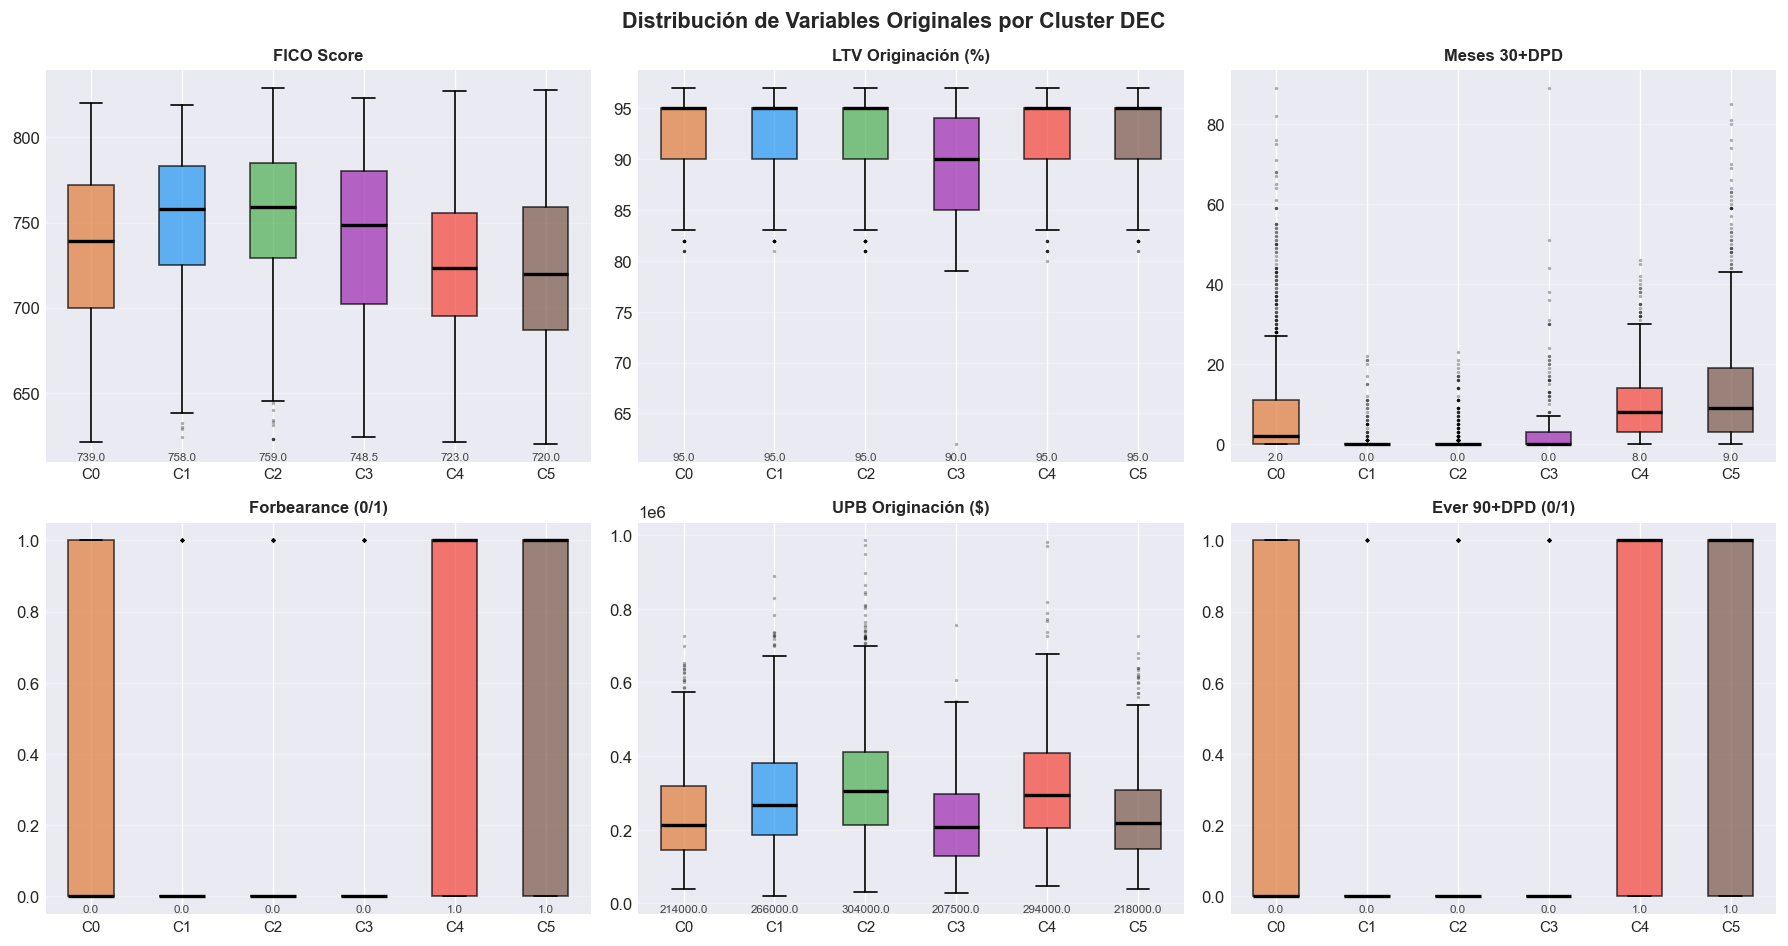

In [12]:
# Fig: Boxplots de variables originales clave
box_vars = [
    ('borrower_credit_score', 'FICO Score'),
    ('orig_ltv',              'LTV Originación (%)'),
    ('months_delinquent_30plus', 'Meses 30+DPD'),
    ('had_forbearance',       'Forbearance (0/1)'),
    ('orig_upb',              'UPB Originación ($)'),
    ('ever_d90',              'Ever 90+DPD (0/1)'),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Variables Originales por Cluster DEC',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (col, label) in zip(axes, box_vars):
    data = [df.loc[df[CLUSTER_COL] == c, col].dropna().values for c in range(K)]
    bp   = ax.boxplot(data, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], PALETTE_LIST):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, K + 1))
    ax.set_xticklabels([f'C{c}' for c in range(K)], fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ymin = ax.get_ylim()[0]
    for i, d in enumerate(data):
        if len(d) > 0:
            ax.text(i + 1, ymin, f'{np.median(d):.1f}',
                    ha='center', va='bottom', fontsize=7, color='#444')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_boxplots_originales.png', dpi=150, bbox_inches='tight')
plt.show()


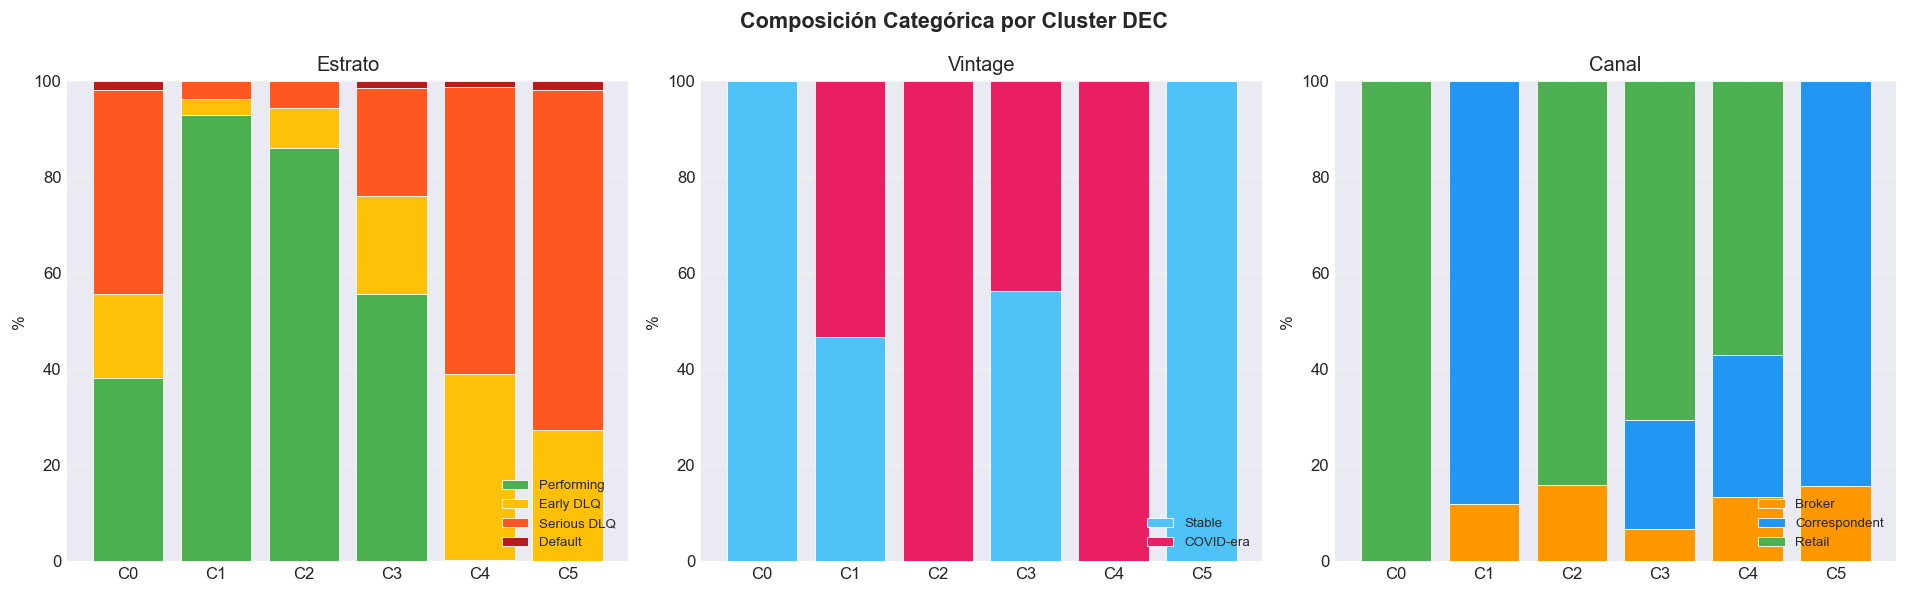

In [13]:
# Fig: Composición categórica (stratum, vintage, canal)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Composición Categórica por Cluster DEC', fontsize=13, fontweight='bold')

strat_c = {'performing': '#4CAF50', 'early_dlq': '#FFC107',
           'serious_dlq': '#FF5722', 'default': '#B71C1C'}
vint_c  = {'Pre-crisis': '#37474F', 'Recovery': '#78909C',
           'Stable': '#4FC3F7', 'COVID-era': '#E91E63'}
chan_c  = {'B': '#FF9800', 'C': '#2196F3', 'R': '#4CAF50'}

for ax, (col, color_map, title, order) in zip(axes, [
    ('stratum',     strat_c, 'Estrato',  ['performing','early_dlq','serious_dlq','default']),
    ('vintage_bin', vint_c,  'Vintage',  ['Pre-crisis','Recovery','Stable','COVID-era']),
    ('channel',     chan_c,  'Canal',    ['B','C','R']),
]):
    ct = pd.crosstab(df[CLUSTER_COL], df[col], normalize='index').mul(100)
    bottom = np.zeros(K)
    for cat in order:
        if cat in ct.columns:
            vals = ct[cat].values
            lbl  = {'B': 'Broker', 'C': 'Correspondent', 'R': 'Retail',
                    'performing': 'Performing', 'early_dlq': 'Early DLQ',
                    'serious_dlq': 'Serious DLQ', 'default': 'Default'}.get(cat, cat)
            ax.bar(range(K), vals, bottom=bottom, color=color_map.get(cat, '#999'),
                   label=lbl, edgecolor='white', linewidth=0.5)
            bottom += vals
    ax.set_xticks(range(K))
    ax.set_xticklabels([f'C{c}' for c in range(K)])
    ax.set(title=title, ylabel='%')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig05_composicion_categorica.png', dpi=150, bbox_inches='tight')
plt.show()


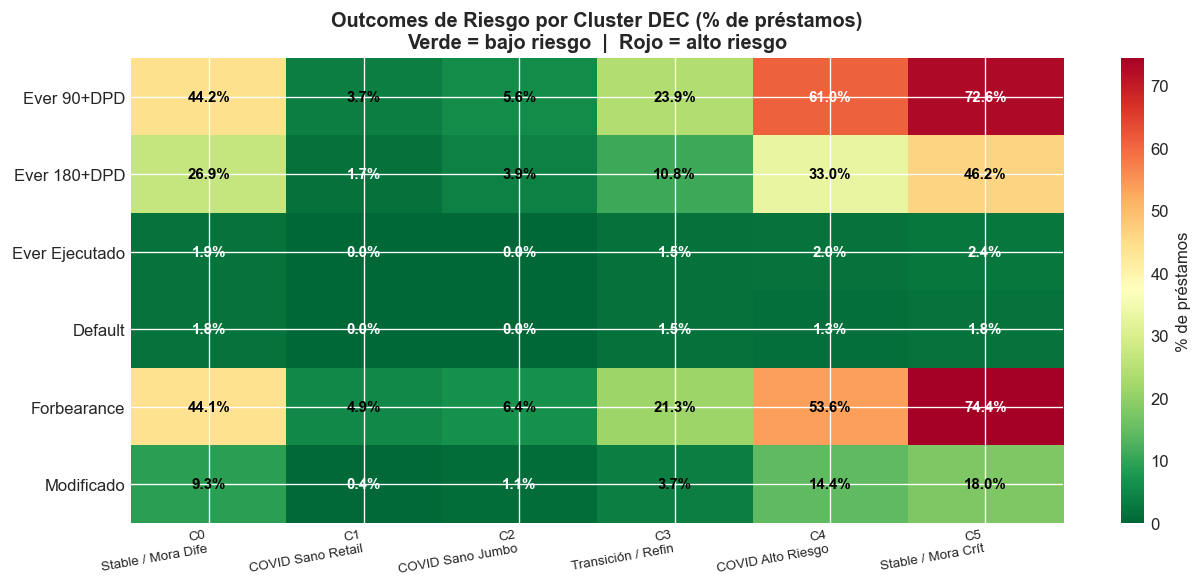

In [14]:
# Fig: Heatmap de outcomes de riesgo
risk_vars   = ['ever_d90', 'ever_d180', 'ever_foreclosed', 'is_default',
               'had_forbearance', 'ever_modified']
risk_labels = ['Ever 90+DPD', 'Ever 180+DPD', 'Ever Ejecutado',
               'Default', 'Forbearance', 'Modificado']

risk_means = pd.DataFrame(
    {c: df[df[CLUSTER_COL] == c][risk_vars].mean().values * 100
     for c in range(K)},
    index=risk_labels
)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(risk_means.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(K))
ax.set_xticklabels([f'C{c}\n{CLUSTER_NAMES[c][:18]}' for c in range(K)],
                   fontsize=8, rotation=10, ha='right')
ax.set_yticks(range(len(risk_labels)))
ax.set_yticklabels(risk_labels, fontsize=10)
ax.set_title('Outcomes de Riesgo por Cluster DEC (% de préstamos)\n'
             'Verde = bajo riesgo  |  Rojo = alto riesgo',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='% de préstamos')
for i in range(len(risk_labels)):
    for j in range(K):
        val   = risk_means.values[i, j]
        color = 'white' if val > 55 or val < 3 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig06_risk_outcomes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Nombres narrativos automáticos

Generados a partir de los factores AFE dominantes en cada cluster.
La lógica de clasificación sigue las reglas de la teoría financiera de riesgo.


In [15]:
def clasificar(cl, prof_norm):
    cred  = prof_norm.loc[cl, 'orig_F_crediticia']
    apal  = prof_norm.loc[cl, 'orig_F_apalancamiento']
    det   = prof_norm.loc[cl, 'comp_F_deterioro']
    macro = prof_norm.loc[cl, 'macro_F_cohorte']
    expo  = prof_norm.loc[cl, 'orig_F_exposicion']

    if det > 0.70 and cred < 0.40:
        return 'ALTO RIESGO — deterioro alto, crédito débil'
    elif cred > 0.70 and det < 0.30:
        return 'BAJO RIESGO — crédito sólido, sin deterioro'
    elif apal > 0.70:
        return 'ALTO APALANCAMIENTO — deuda elevada relativa al valor'
    elif macro > 0.70:
        return 'RIESGO MACROECONÓMICO — cohorte de alta exposición'
    elif det < 0.30 and cred > 0.50:
        return 'MADURO ESTABLE — historial limpio, crédito adecuado'
    else:
        return 'RIESGO MODERADO — perfil intermedio'

perfiles_auto = {cl: clasificar(cl, prof_norm) for cl in prof_norm.index}

print('PERFILES NARRATIVOS AUTOMÁTICOS — DEC')
print('=' * 70)
for cl, nombre in perfiles_auto.items():
    n   = prof_afe.loc[cl, 'n_loans']
    pct = prof_afe.loc[cl, 'pct_%']
    print(f'  Cluster {cl}: {nombre}')
    print(f'             {n:,} loans — {pct:.1f}% del portfolio')
    print(f'             [Nombre descriptivo: {CLUSTER_NAMES[cl]}]')
    print()


PERFILES NARRATIVOS AUTOMÁTICOS — DEC
  Cluster 0: ALTO APALANCAMIENTO — deuda elevada relativa al valor
             1,295 loans — 24.6% del portfolio
             [Nombre descriptivo: Stable / Mora Diferida]

  Cluster 1: ALTO APALANCAMIENTO — deuda elevada relativa al valor
             931 loans — 17.7% del portfolio
             [Nombre descriptivo: COVID Sano Retail]

  Cluster 2: BAJO RIESGO — crédito sólido, sin deterioro
             1,142 loans — 21.7% del portfolio
             [Nombre descriptivo: COVID Sano Jumbo]

  Cluster 3: BAJO RIESGO — crédito sólido, sin deterioro
             268 loans — 5.1% del portfolio
             [Nombre descriptivo: Transición / Refinanciamiento]

  Cluster 4: ALTO APALANCAMIENTO — deuda elevada relativa al valor
             707 loans — 13.4% del portfolio
             [Nombre descriptivo: COVID Alto Riesgo]

  Cluster 5: ALTO RIESGO — deterioro alto, crédito débil
             924 loans — 17.5% del portfolio
             [Nombre descriptiv

## 8. Impacto de negocio

### Tarificación diferencial (Pricing)

Un portfolio con tasa uniforme **subsidia el riesgo alto con el riesgo bajo**.
La segmentación DEC permite asignar spreads basados en el perfil real de cada cluster:

| Cluster | Perfil | Acción de pricing |
|---|---|---|
| C1, C2 | Bajo riesgo | Tasa competitiva para retener al cliente |
| C3 | Riesgo moderado | Pricing por LTV y vintage |
| C0 | Moderado-alto | Spread ajustado, monitoreo trimestral |
| C4 | Alto riesgo | Spread mayor, monitoreo mensual obligatorio |
| C5 | Muy alto riesgo | Spread máximo, colateral adicional, revisión inmediata |

### Monitoreo proactivo de cartera

En lugar de revisar los 5,267 loans individualmente:

1. **Alertas tempranas** enfocadas en C4 y C5 (`comp_F_deterioro` alto)
2. **Revisión trimestral** para C0 (`macro_F_cohorte` + forbearance)
3. **Frecuencia reducida** para C1 y C2 (comportamiento limpio comprobado)
4. **Revisión manual** para loans con `n_acuerdos < 6` (asignación incierta)

### Gestión de loans con baja confianza de asignación

Los loans donde los 4 métodos **no coinciden** son los más ambiguos
en el espacio latente. Criterio conservador: asignarlos al cluster de
mayor riesgo adyacente para evitar subestimar la exposición.


## 9. Exportar resultados

In [16]:
# 1. Perfiles AFE por cluster
prof_afe.to_csv(OUT_DIR / 'perfiles_afe_dec.csv')

# 2. Perfiles observables (medias y medianas)
means.to_csv(OUT_DIR / 'perfiles_medias_originales.csv')
medians.to_csv(OUT_DIR / 'perfiles_medianas_originales.csv')

# 3. Perfiles narrativos
df_perfiles = pd.DataFrame([
    {'cluster': cl,
     'perfil_auto': perfiles_auto[cl],
     'nombre_descriptivo': CLUSTER_NAMES[cl],
     'nivel_riesgo': RISK_LEVEL[cl],
     'n_loans': int(prof_afe.loc[cl, 'n_loans']),
     'pct_portfolio': float(prof_afe.loc[cl, 'pct_%'])}
    for cl in range(K)
])
df_perfiles.to_csv(OUT_DIR / 'perfiles_narrativos.csv', index=False)

# 4. ARI y confianza por loan
ari_mat.to_csv(OUT_DIR / 'ari_estabilidad.csv')
df[['loan_id_str', CLUSTER_COL, 'n_acuerdos', 'alta_confianza']].to_csv(
    OUT_DIR / 'loans_confianza.csv', index=False)

print('Archivos exportados en', OUT_DIR)
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')


Archivos exportados en output_caracterizacion
  ari_estabilidad.csv
  fig01_ari_estabilidad.png
  fig02_perfiles_afe.png
  fig03_boxplots_afe.png
  fig04_boxplots_originales.png
  fig05_composicion_categorica.png
  fig06_risk_outcomes_heatmap.png
  loans_confianza.csv
  perfiles_afe_dec.csv
  perfiles_medianas_originales.csv
  perfiles_medias_originales.csv
  perfiles_narrativos.csv


## 10. Resumen ejecutivo

In [17]:
pct_conf = df['alta_confianza'].mean() * 100

print('=' * 72)
print('  RESUMEN — Fase IV: Caracterización de Perfiles de Riesgo')
print('=' * 72)
print(f'\n  Loans analizados  : {len(df):,}')
print(f'  Método canónico   : DEC (Deep Embedded Clustering)')
print(f'  K clusters        : {K}')
print(f'  Alta confianza    : {pct_conf:.1f}% (4 métodos coinciden)')
print(f'  Para revisión     : {100-pct_conf:.1f}% (discrepancia entre métodos)')
print()
print(f'  {"Cluster":<6} {"Nombre":<32} {"N":>6} {"%":>6} '
      f'{"FICO":>6} {"LTV":>6} {"Ever90%":>8} {"Forb%":>7} {"Riesgo"}')
print('  ' + '-' * 85)
for c in range(K):
    n   = (df[CLUSTER_COL] == c).sum()
    pct = n / len(df) * 100
    print(f'  C{c:<5} {CLUSTER_NAMES[c]:<32} {n:>6,} {pct:>5.1f}% '
          f'{means.loc[c,"borrower_credit_score"]:>6.0f} '
          f'{means.loc[c,"orig_ltv"]:>5.1f}% '
          f'{means.loc[c,"ever_d90"]*100:>7.1f}% '
          f'{means.loc[c,"had_forbearance"]*100:>6.1f}% '
          f'  {RISK_LEVEL[c]}')
print()
print('  Figuras generadas:')
for fig_name in sorted(OUT_DIR.glob('fig*.png')):
    print(f'  ✓ {fig_name.name}')


  RESUMEN — Fase IV: Caracterización de Perfiles de Riesgo

  Loans analizados  : 5,267
  Método canónico   : DEC (Deep Embedded Clustering)
  K clusters        : 6
  Alta confianza    : 0.0% (4 métodos coinciden)
  Para revisión     : 100.0% (discrepancia entre métodos)

  Cluster Nombre                                N      %   FICO    LTV  Ever90%   Forb% Riesgo
  -------------------------------------------------------------------------------------
  C0     Stable / Mora Diferida            1,295  24.6%    734  92.6%    44.2%   44.1%   MODERADO-ALTO
  C1     COVID Sano Retail                   931  17.7%    751  92.9%     3.7%    4.9%   BAJO
  C2     COVID Sano Jumbo                  1,142  21.7%    753  92.2%     5.6%    6.4%   BAJO
  C3     Transición / Refinanciamiento       268   5.1%    739  89.3%    23.9%   21.3%   MODERADO
  C4     COVID Alto Riesgo                   707  13.4%    725  93.0%    61.0%   53.6%   ALTO
  C5     Stable / Mora Crítica               924  17.5%    72

Validación de estabilidad temporal frente a choques economicos 

In [18]:
df.groupby(['vintage_year', 'cluster_dec'])['is_default'].mean()

KeyError: 'vintage_year'